In [ ]:
# -- 2.1 Collect the Data --

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [64]:
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")

In [65]:
print("shape:", df.shape)
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

shape: (100, 6)
number of rows: 100
number of columns: 6


In [66]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [67]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [68]:
df.columns

Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

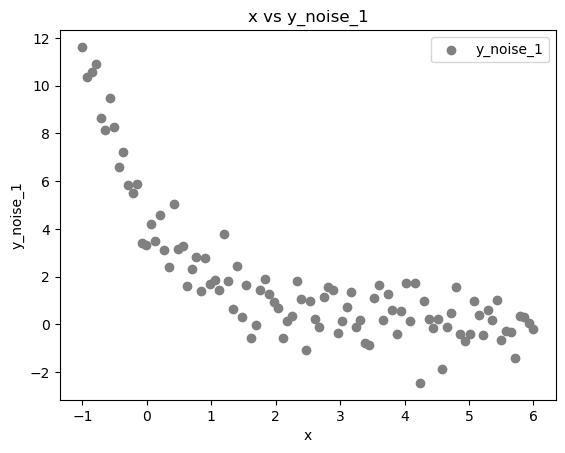

In [69]:
plt.scatter(df["x"], df["y_noise_1"], color="gray", label="y_noise_1")
plt.title("x vs y_noise_1")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.legend()
plt.show()

In [70]:
# -- 2.2 Fit the Data --

In [71]:
def model(x, A, k):
    return A * np.exp(-k * x)

In [72]:
x = df["x"].values
y_noise_1 = df["y_noise_1"].values

In [73]:
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [74]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

print(f"reduced chi-squared: {chi2_reduced:.2f}")

reduced chi-squared: 0.79


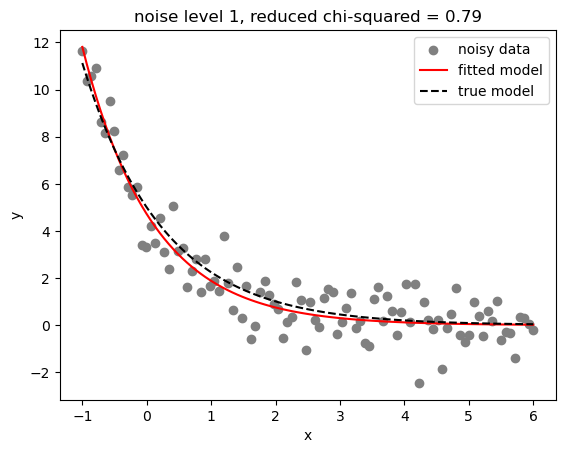

In [75]:
plt.scatter(x, y_noise_1, color="gray", label="noisy data")
plt.plot(x, model(x, A_fit, k_fit), color="red", label="fitted model")
plt.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="true model")


plt.title(f"noise level 1, reduced chi-squared = {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [76]:
# -- 2.3 Compare Different Noise Levels --

In [77]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return A_fit, k_fit, chi2_reduced
    

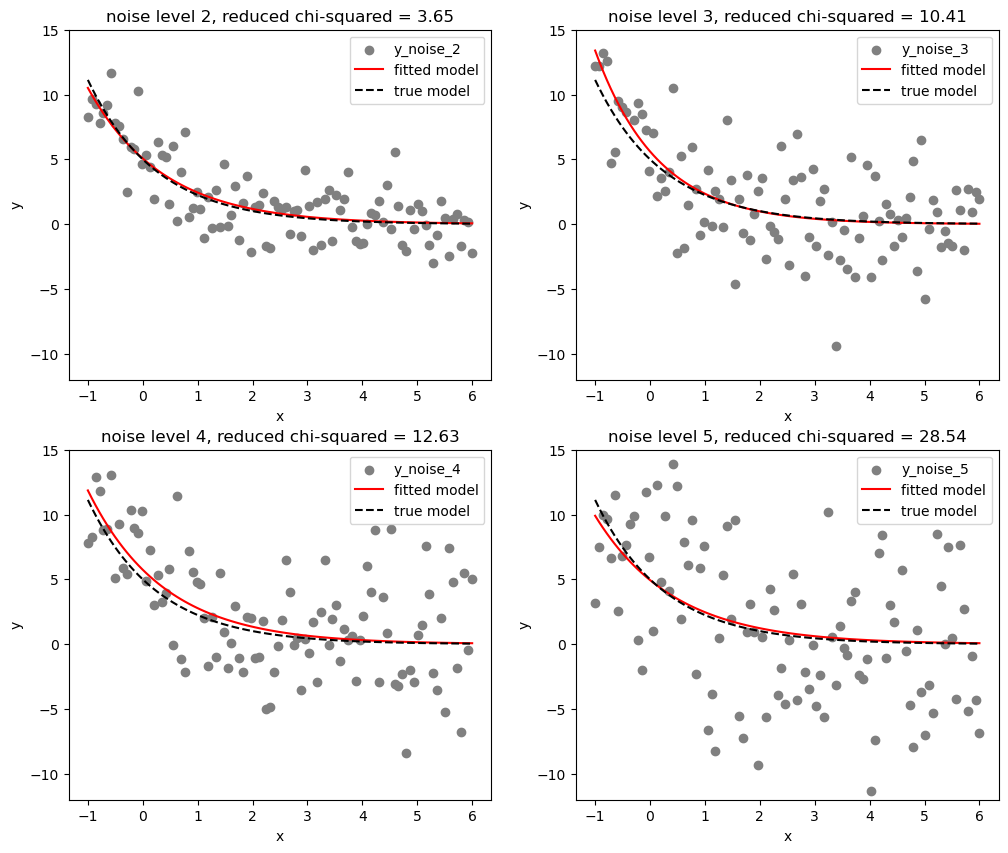

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()
noise_levels = [2, 3, 4, 5]

for i, noise in enumerate(noise_levels):
    y = df[f"y_noise_{noise}"].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    axes[i].scatter(x, y, color="gray", label=f"y_noise_{noise}")
    axes[i].plot(x, model(x, A_fit, k_fit), color="red", label="fitted model")
    axes[i].plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="true model")
    
    axes[i].set_title(f"noise level {noise}, reduced chi-squared = {chi2_reduced:.2f}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    axes[i].set_ylim(-12, 15)
    axes[i].legend()
    

plt.show()


•What happens to the red and black dotted lines as you increase the noise level? Why?
As the noise level increases, the red fitted line still stays close to the black dotted true model, but the difference between them becomes a little larger. This is becuase the data points become more scattered, so the fitting is affected more. 


• What happens to the reduced chi-squared as you increase the noise level? Why?
The reduced chi-squared becomes larger. This is because the residuls between the data and the fitted model become bigger when the data are noiser, so the fit becomes worse. 

In [79]:
noise_levels = [1, 2, 3, 4, 5]
noise_list = []
A_list = []
k_list = []
chi2_list = []

for noise in noise_levels:
    y = df[f"y_noise_{noise}"].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    noise_list.append(noise)
    A_list.append(A_fit)
    k_list.append(k_fit)
    chi2_list.append(chi2_reduced)
    
new_df = pd.DataFrame({
    "noise level": noise_list,
    "A fit": A_list,
    "k fit": k_list,
    "reduced chi-square": chi2_list
})

In [80]:
new_df.to_csv("noisy_parameters.csv", index=False)